In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from math import nan

sys.path.append("/glade/u/home/islas/python/CESM2_with_CMIP7_aer/utils/")

from convert_units import *
from molecular_weights import *

from CASutils import calendar_utils as cal


In [8]:
basepath="/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/"
bens = xr.open_dataset(basepath+
                       "so4_a1_ag_ship_slv-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc")

my_ag = xr.open_dataset(basepath+
                        "so4_a1_ag_emissions_ne30pg3.nc")

my_ship = xr.open_dataset(basepath+
                          "so4_a1_ship_emissions_ne30pg3.nc")

my_slv_was = xr.open_dataset(basepath+
                             "so4_a1_slv_was_emissions_ne30pg3.nc")

In [9]:
bens_tg = convert_molecules_to_tg_specifywgt(bens.emiss, mol_weights['so4_a1'])
my_ag_tg = convert_molecules_to_tg_specifywgt(my_ag.emiss, mol_weights['so4_a1'])
my_ship_tg = convert_molecules_to_tg_specifywgt(my_ship.emiss, mol_weights['so4_a1'])
my_slv_was_tg = convert_molecules_to_tg_specifywgt(my_slv_was.emiss, mol_weights['so4_a1'])

In [10]:
bens_tg_am = cal.calcannualmean(bens_tg)
my_ag_tg_am = cal.calcannualmean(my_ag_tg)
my_ship_tg_am = cal.calcannualmean(my_ship_tg)
my_slv_was_tg_am = cal.calcannualmean(my_slv_was_tg)

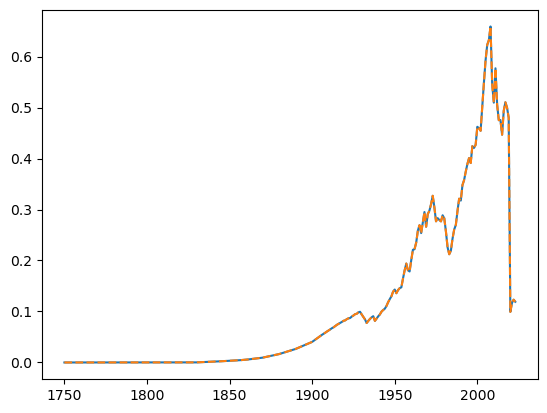

In [15]:
plt.plot(bens_tg_am.year, bens_tg_am)
plt.plot(my_ag_tg_am.year, my_ag_tg_am + my_ship_tg_am + my_slv_was_tg_am, linestyle='dashed')